## 10. Entraînement et Évaluation Complète des 6 Modèles

### Cette section contient le code complet pour:
1. **Entraîner** les 6 modèles sur ISIC 2019
2. **Évaluer** les performances de classification
3. **Comparer** les méthodes XAI de façon exhaustive
4. **Générer** les figures pour la thèse

### Prérequis:
- Dataset ISIC 2019 téléchargé
- GPU avec 8-24 GB VRAM
- ~2-6 heures par modèle pour l'entraînement

## 1. Installation et Configuration

In [ ]:
# ============================================
# INSTALLATION DES DÉPENDANCES
# ============================================
# Décommenter et exécuter si nécessaire

!pip install torch torchvision --index-url https://download.pytorch.org/whl/cu118
!pip install timm==0.9.12
!pip install pytorch-grad-cam==1.5.0
!pip install captum==0.7.0
!pip install lime==0.2.0.1
!pip install albumentations==1.3.1
!pip install scikit-learn pandas matplotlib seaborn tqdm

In [2]:
# ============================================
# IMPORTS
# ============================================
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2
from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings('ignore')

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
import timm

# XAI Libraries
from captum.attr import IntegratedGradients, Saliency

# Configuration
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# Ajouter le path du projet
sys.path.insert(0, '..')

# Seed pour reproductibilité
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

Device: cpu


## 2. Configuration et Constantes

In [3]:
# ============================================
# CONFIGURATION
# ============================================

# Dataset - AJUSTER SELON VOTRE CONFIGURATION
DATA_DIR = '../data/ISIC2019'
IMAGE_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 4

# Classes ISIC 2019 (8 classes)
CLASS_NAMES = ['MEL', 'NV', 'BCC', 'AK', 'BKL', 'DF', 'VASC', 'SCC']

CLASS_NAMES_FULL = {
    'MEL': 'Melanome',
    'NV': 'Naevus melanocytaire',
    'BCC': 'Carcinome basocellulaire',
    'AK': 'Keratose actinique',
    'BKL': 'Keratose benigne',
    'DF': 'Dermatofibrome',
    'VASC': 'Lesion vasculaire',
    'SCC': 'Carcinome epidermoide'
}

NUM_CLASSES = len(CLASS_NAMES)

# Normalisation ImageNet
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

print(f"Configuration:")
print(f"   - Image size: {IMAGE_SIZE}x{IMAGE_SIZE}")
print(f"   - Batch size: {BATCH_SIZE}")
print(f"   - Nombre de classes: {NUM_CLASSES}")
print(f"\nClasses ISIC 2019:")
for i, (abbr, full) in enumerate(CLASS_NAMES_FULL.items()):
    print(f"   {i}. {abbr}: {full}")

Configuration:
   - Image size: 224x224
   - Batch size: 32
   - Nombre de classes: 8

Classes ISIC 2019:
   0. MEL: Melanome
   1. NV: Naevus melanocytaire
   2. BCC: Carcinome basocellulaire
   3. AK: Keratose actinique
   4. BKL: Keratose benigne
   5. DF: Dermatofibrome
   6. VASC: Lesion vasculaire
   7. SCC: Carcinome epidermoide


## 3. Vérification du Dataset

In [4]:
# ============================================
# VÉRIFIER LE DATASET
# ============================================

dataset_available = os.path.exists(DATA_DIR)

if dataset_available:
    csv_path = os.path.join(DATA_DIR, 'ISIC_2019_Training_GroundTruth.csv')
    img_dir = os.path.join(DATA_DIR, 'ISIC_2019_Training_Input')
    
    if os.path.exists(csv_path) and os.path.exists(img_dir):
        df = pd.read_csv(csv_path)
        print(f"Dataset ISIC trouve!")
        print(f"\nStatistiques:")
        print(f"   - Total images: {len(df)}")
        print(f"\nDistribution des classes:")
        for cls in CLASS_NAMES:
            if cls in df.columns:
                count = df[cls].sum()
                pct = count / len(df) * 100
                print(f"   - {cls}: {count:,} ({pct:.1f}%)")
    else:
        dataset_available = False

if not dataset_available:
    print("Dataset ISIC non trouve!")
    print("\nInstructions de telechargement:")
    print("   1. Aller sur: https://challenge.isic-archive.com/data/#2019")
    print("   2. Telecharger 'ISIC_2019_Training_Input.zip' (~9GB)")
    print("   3. Telecharger 'ISIC_2019_Training_GroundTruth.csv'")
    print(f"   4. Extraire dans: {DATA_DIR}")
    print("\n   Structure attendue:")
    print("   data/ISIC2019/")
    print("   ├── ISIC_2019_Training_Input/")
    print("   │   ├── ISIC_0000000.jpg")
    print("   │   └── ...")
    print("   └── ISIC_2019_Training_GroundTruth.csv")

Dataset ISIC trouve!

Statistiques:
   - Total images: 25331

Distribution des classes:
   - MEL: 4,522.0 (17.9%)
   - NV: 12,875.0 (50.8%)
   - BCC: 3,323.0 (13.1%)
   - AK: 867.0 (3.4%)
   - BKL: 2,624.0 (10.4%)
   - DF: 239.0 (0.9%)
   - VASC: 253.0 (1.0%)
   - SCC: 628.0 (2.5%)


## 4. Création des Modèles

In [5]:
# ============================================
# WRAPPER DE MODÈLES
# ============================================

class ModelWrapper(nn.Module):
    """Wrapper unifie pour CNN et ViT."""
    
    def __init__(self, model_name, num_classes, pretrained=True):
        super().__init__()
        self.model_name = model_name
        self.num_classes = num_classes
        
        # Creer le modele avec timm
        self.model = timm.create_model(
            model_name, 
            pretrained=pretrained, 
            num_classes=num_classes
        )
        
        # Determiner le type de modele
        self.model_type = self._get_model_type()
        
    def _get_model_type(self):
        vit_keywords = ['vit', 'deit', 'swin', 'beit']
        if any(kw in self.model_name.lower() for kw in vit_keywords):
            return 'transformer'
        return 'cnn'
    
    def forward(self, x):
        return self.model(x)
    
    def get_target_layer(self):
        """Obtenir la couche cible pour Grad-CAM."""
        if 'resnet' in self.model_name:
            return self.model.layer4[-1]
        elif 'efficientnet' in self.model_name:
            return self.model.conv_head
        elif 'vit' in self.model_name or 'deit' in self.model_name:
            return self.model.blocks[-1].norm1
        elif 'swin' in self.model_name:
            return self.model.layers[-1].blocks[-1].norm1
        elif 'convnext' in self.model_name:
            return self.model.stages[-1].blocks[-1]
        else:
            return list(self.model.children())[-2]

In [6]:
# ============================================
# CRÉER LES 6 MODÈLES
# ============================================

print("Chargement des 6 modèles...\n")

# Configuration des 6 modèles
MODELS_CONFIG = {
    # CNN Classiques
    'resnet50': {'timm_name': 'resnet50', 'type': 'CNN', 'batch_size': 32, 'lr': 1e-4},
    'efficientnet_b4': {'timm_name': 'efficientnet_b4', 'type': 'CNN', 'batch_size': 24, 'lr': 1e-4},
    # CNN Moderne
    'convnext_base': {'timm_name': 'convnext_base', 'type': 'CNN-Modern', 'batch_size': 16, 'lr': 5e-5},
    # Vision Transformers
    'vit_base': {'timm_name': 'vit_base_patch16_224', 'type': 'Transformer', 'batch_size': 16, 'lr': 1e-5},
    'deit_base': {'timm_name': 'deit_base_patch16_224', 'type': 'Transformer', 'batch_size': 16, 'lr': 1e-5},
    'swin_base': {'timm_name': 'swin_base_patch4_window7_224', 'type': 'Transformer', 'batch_size': 16, 'lr': 1e-5},
}

models = {}

for name, cfg in MODELS_CONFIG.items():
    print(f"{name} ({cfg['type']})...")
    try:
        models[name] = ModelWrapper(cfg['timm_name'], NUM_CLASSES, pretrained=True).to(device)
        models[name].eval()
        params = sum(p.numel() for p in models[name].parameters())
        print(f"   ✓ {params/1e6:.1f}M parametres")
    except Exception as e:
        print(f"   ✗ Erreur: {e}")

print(f"\n{'='*50}")
print(f"✓ {len(models)}/6 modèles chargés!")
print(f"{'='*50}")

Chargement des 6 modèles...

resnet50 (CNN)...
   ✓ 23.5M parametres
efficientnet_b4 (CNN)...


model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]

   ✓ 17.6M parametres
convnext_base (CNN-Modern)...


model.safetensors:   0%|          | 0.00/354M [00:00<?, ?B/s]

   ✓ 87.6M parametres
vit_base (Transformer)...
   ✓ 85.8M parametres
deit_base (Transformer)...


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

   ✓ 85.8M parametres
swin_base (Transformer)...


model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

   ✓ 86.8M parametres

✓ 6/6 modèles chargés!


## 5. Méthodes XAI

In [7]:
# ============================================
# 5.1 GRAD-CAM
# ============================================

class GradCAMExplainer:
    """Grad-CAM pour CNN et ViT."""
    
    def __init__(self, model, device='cuda'):
        self.model = model
        self.device = device
        self.target_layer = model.get_target_layer()
        self.gradients = None
        self.activations = None
        
        self.target_layer.register_forward_hook(self._save_activation)
        self.target_layer.register_full_backward_hook(self._save_gradient)
    
    def _save_activation(self, module, input, output):
        self.activations = output.detach()
    
    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()
    
    def explain(self, input_tensor, target_class=None):
        self.model.eval()
        input_tensor = input_tensor.to(self.device)
        input_tensor.requires_grad = True
        
        output = self.model(input_tensor)
        
        if target_class is None:
            target_class = output.argmax(dim=1).item()
        
        self.model.zero_grad()
        one_hot = torch.zeros_like(output)
        one_hot[0, target_class] = 1
        output.backward(gradient=one_hot, retain_graph=True)
        
        gradients = self.gradients
        activations = self.activations
        
        # Pour ViT: reshape si necessaire
        if self.model.model_type == 'transformer':
            if len(activations.shape) == 3:
                num_patches = activations.shape[1]
                if num_patches == 197:
                    activations = activations[:, 1:, :]
                    gradients = gradients[:, 1:, :]
                    num_patches = 196
                
                h = w = int(np.sqrt(num_patches))
                activations = activations.reshape(1, h, w, -1).permute(0, 3, 1, 2)
                gradients = gradients.reshape(1, h, w, -1).permute(0, 3, 1, 2)
        
        weights = gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * activations).sum(dim=1, keepdim=True)
        cam = F.relu(cam)
        cam = F.interpolate(cam, size=(224, 224), mode='bilinear', align_corners=False)
        
        cam = cam.squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        
        return cam

print("GradCAMExplainer defini")

GradCAMExplainer defini


In [8]:
# ============================================
# 5.2 ATTENTION ROLLOUT
# ============================================

class AttentionRolloutExplainer:
    """Attention Rollout pour Vision Transformers."""
    
    def __init__(self, model, device='cuda'):
        if model.model_type != 'transformer':
            raise ValueError("Attention Rollout uniquement pour les Transformers")
        self.model = model
        self.device = device
    
    def explain(self, input_tensor, target_class=None, head_fusion='mean'):
        self.model.eval()
        input_tensor = input_tensor.to(self.device)
        
        attentions = []
        
        def hook_fn(module, input, output):
            B, N, C = input[0].shape
            qkv = module.qkv(input[0]).reshape(B, N, 3, module.num_heads, C // module.num_heads)
            qkv = qkv.permute(2, 0, 3, 1, 4)
            q, k, v = qkv[0], qkv[1], qkv[2]
            attn = (q @ k.transpose(-2, -1)) * (C // module.num_heads) ** -0.5
            attn = attn.softmax(dim=-1)
            attentions.append(attn.detach().cpu())
        
        hooks = []
        for block in self.model.model.blocks:
            hooks.append(block.attn.register_forward_hook(hook_fn))
        
        with torch.no_grad():
            _ = self.model(input_tensor)
        
        for hook in hooks:
            hook.remove()
        
        result = torch.eye(attentions[0].shape[-1])
        
        for attention in attentions:
            if head_fusion == 'mean':
                attention_heads_fused = attention.mean(dim=1)
            elif head_fusion == 'max':
                attention_heads_fused = attention.max(dim=1)[0]
            else:
                attention_heads_fused = attention.min(dim=1)[0]
            
            I = torch.eye(attention_heads_fused.shape[-1])
            a = (attention_heads_fused + I) / 2
            a = a / a.sum(dim=-1, keepdim=True)
            result = torch.matmul(a.squeeze(0), result)
        
        mask = result[0, 1:]
        num_patches = mask.shape[0]
        h = w = int(np.sqrt(num_patches))
        mask = mask.reshape(h, w).numpy()
        mask = cv2.resize(mask, (224, 224))
        mask = (mask - mask.min()) / (mask.max() - mask.min() + 1e-8)
        
        return mask

print("AttentionRolloutExplainer defini")

AttentionRolloutExplainer defini


In [9]:
# ============================================
# 5.3 GENERIC ATTENTION (CHEFER ET AL.)
# ============================================

class GenericAttentionExplainer:
    """
    Generic Attention pour ViT (Chefer et al., CVPR 2021).
    Reference: "Transformer Interpretability Beyond Attention Visualization"
    """
    
    def __init__(self, model, device='cuda'):
        if model.model_type != 'transformer':
            raise ValueError("Generic Attention uniquement pour les Transformers")
        self.model = model
        self.device = device
    
    def explain(self, input_tensor, target_class=None):
        self.model.eval()
        input_tensor = input_tensor.to(self.device)
        input_tensor.requires_grad = True
        
        attentions = []
        
        def forward_hook(module, input, output):
            B, N, C = input[0].shape
            qkv = module.qkv(input[0]).reshape(B, N, 3, module.num_heads, C // module.num_heads)
            qkv = qkv.permute(2, 0, 3, 1, 4)
            q, k, v = qkv[0], qkv[1], qkv[2]
            attn = (q @ k.transpose(-2, -1)) * (C // module.num_heads) ** -0.5
            attn = attn.softmax(dim=-1)
            attentions.append(attn)
        
        hooks = []
        for block in self.model.model.blocks:
            hooks.append(block.attn.register_forward_hook(forward_hook))
        
        output = self.model(input_tensor)
        
        if target_class is None:
            target_class = output.argmax(dim=1).item()
        
        self.model.zero_grad()
        one_hot = torch.zeros_like(output)
        one_hot[0, target_class] = 1
        output.backward(gradient=one_hot, retain_graph=True)
        
        for hook in hooks:
            hook.remove()
        
        num_tokens = attentions[0].shape[-1]
        R = torch.eye(num_tokens, device=self.device)
        
        for attn in attentions:
            attn = attn.squeeze(0)
            attn = attn.mean(dim=0)
            I = torch.eye(num_tokens, device=self.device)
            attn = (attn + I) / 2
            attn = attn / attn.sum(dim=-1, keepdim=True)
            R = torch.matmul(attn, R)
        
        mask = R[0, 1:].cpu().detach().numpy()
        num_patches = mask.shape[0]
        h = w = int(np.sqrt(num_patches))
        mask = mask.reshape(h, w)
        mask = cv2.resize(mask, (224, 224))
        mask = (mask - mask.min()) / (mask.max() - mask.min() + 1e-8)
        
        return mask

print("GenericAttentionExplainer defini (Chefer et al.)")

GenericAttentionExplainer defini (Chefer et al.)


In [10]:
# ============================================
# 5.4 INTEGRATED GRADIENTS
# ============================================

class IntegratedGradientsExplainer:
    """Integrated Gradients (Sundararajan et al., ICML 2017)."""
    
    def __init__(self, model, device='cuda', n_steps=50):
        self.model = model
        self.device = device
        self.n_steps = n_steps
        self.ig = IntegratedGradients(model)
    
    def explain(self, input_tensor, target_class=None, baseline=None):
        self.model.eval()
        input_tensor = input_tensor.to(self.device)
        
        if target_class is None:
            with torch.no_grad():
                output = self.model(input_tensor)
                target_class = output.argmax(dim=1).item()
        
        if baseline is None:
            baseline = torch.zeros_like(input_tensor).to(self.device)
        
        attributions = self.ig.attribute(
            input_tensor,
            baselines=baseline,
            target=target_class,
            n_steps=self.n_steps,
            return_convergence_delta=False
        )
        
        attr = attributions.squeeze().cpu().numpy()
        saliency = np.abs(attr).sum(axis=0)
        saliency = (saliency - saliency.min()) / (saliency.max() - saliency.min() + 1e-8)
        
        return saliency

print("IntegratedGradientsExplainer defini")

IntegratedGradientsExplainer defini


In [11]:
# ============================================
# 5.5 LIME
# ============================================

try:
    from lime import lime_image
    LIME_AVAILABLE = True
    
    class LIMEExplainer:
        """LIME (Local Interpretable Model-agnostic Explanations)."""
        
        def __init__(self, model, device='cuda', num_samples=1000):
            self.model = model
            self.device = device
            self.num_samples = num_samples
            self.explainer = lime_image.LimeImageExplainer()
        
        def _predict_fn(self, images):
            batch = []
            transform = transforms.Compose([
                transforms.ToTensor(),
                transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
            ])
            
            for img in images:
                img_pil = Image.fromarray(img.astype('uint8'))
                batch.append(transform(img_pil))
            
            batch = torch.stack(batch).to(self.device)
            
            with torch.no_grad():
                outputs = self.model(batch)
                probs = F.softmax(outputs, dim=1)
            
            return probs.cpu().numpy()
        
        def explain(self, input_tensor, target_class=None, num_features=10):
            self.model.eval()
            
            img = input_tensor.squeeze().cpu().numpy()
            mean = np.array(IMAGENET_MEAN).reshape(3, 1, 1)
            std = np.array(IMAGENET_STD).reshape(3, 1, 1)
            img = (img * std + mean).transpose(1, 2, 0)
            img = (img * 255).astype(np.uint8)
            
            if target_class is None:
                with torch.no_grad():
                    output = self.model(input_tensor.to(self.device))
                    target_class = output.argmax(dim=1).item()
            
            explanation = self.explainer.explain_instance(
                img,
                self._predict_fn,
                top_labels=5,
                hide_color=0,
                num_samples=self.num_samples
            )
            
            temp, mask = explanation.get_image_and_mask(
                target_class,
                positive_only=True,
                num_features=num_features,
                hide_rest=False
            )
            
            return mask.astype(np.float32)
    
    print("LIMEExplainer defini")
    
except ImportError:
    LIME_AVAILABLE = False
    print("LIME non installe. Installer avec: pip install lime")

LIMEExplainer defini


## 6. Démonstration

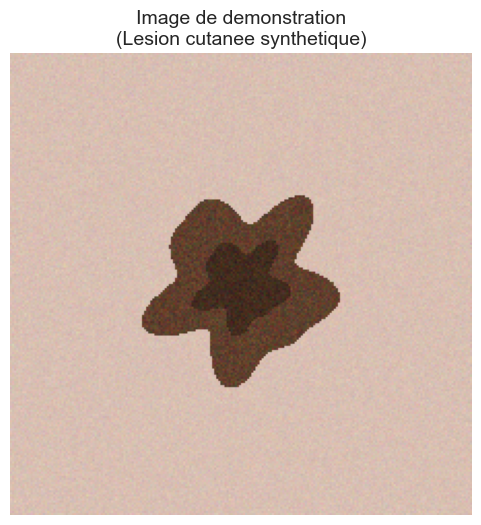

In [12]:
# ============================================
# IMAGE DE DÉMONSTRATION
# ============================================

def create_demo_image():
    """Creer une image de demonstration simulant une lesion cutanee."""
    np.random.seed(42)
    
    img = np.ones((224, 224, 3)) * 0.8
    img[:, :, 0] = 0.85
    img[:, :, 1] = 0.75
    img[:, :, 2] = 0.70
    
    y, x = np.ogrid[:224, :224]
    center_x, center_y = 112, 112
    angles = np.arctan2(y - center_y, x - center_x)
    radius_variation = 40 + 8 * np.sin(5 * angles) + 5 * np.cos(7 * angles)
    distance = np.sqrt((x - center_x)**2 + (y - center_y)**2)
    lesion_mask = distance < radius_variation
    
    img[lesion_mask, 0] = 0.3 + np.random.rand(lesion_mask.sum()) * 0.15
    img[lesion_mask, 1] = 0.2 + np.random.rand(lesion_mask.sum()) * 0.1
    img[lesion_mask, 2] = 0.15 + np.random.rand(lesion_mask.sum()) * 0.05
    
    dark_center = distance < (radius_variation * 0.5)
    img[dark_center, :] *= 0.7
    
    img += np.random.randn(224, 224, 3) * 0.02
    img = np.clip(img, 0, 1)
    
    return img.astype(np.float32)

def preprocess_image(img_array):
    mean = np.array(IMAGENET_MEAN).reshape(1, 1, 3)
    std = np.array(IMAGENET_STD).reshape(1, 1, 3)
    img_normalized = (img_array - mean) / std
    img_tensor = torch.from_numpy(img_normalized.transpose(2, 0, 1)).float()
    return img_tensor.unsqueeze(0)

demo_image = create_demo_image()
demo_tensor = preprocess_image(demo_image).to(device)

plt.figure(figsize=(6, 6))
plt.imshow(demo_image)
plt.title("Image de demonstration\n(Lesion cutanee synthetique)", fontsize=14)
plt.axis('off')
plt.show()

In [13]:
# ============================================
# PRÉDICTIONS DES 6 MODÈLES
# ============================================

print("Predictions des 6 modeles:\n")
print("="*70)
print(f"{'Modèle':<20} {'Type':<15} {'Prediction':^10} {'Confiance':>10}")
print("-"*70)

predictions = {}

for name, model in models.items():
    model_type = MODELS_CONFIG[name]['type']
    with torch.no_grad():
        output = model(demo_tensor)
        probs = F.softmax(output, dim=1)
        pred_class = probs.argmax(dim=1).item()
        confidence = probs.max().item()
        
        predictions[name] = {
            'class': pred_class,
            'confidence': confidence,
            'class_name': CLASS_NAMES[pred_class]
        }
        
        print(f"{name:<20} {model_type:<15} {CLASS_NAMES[pred_class]:^10} {confidence:>10.1%}")

print("="*70)

Predictions des 6 modeles:

Modèle               Type            Prediction  Confiance
----------------------------------------------------------------------
resnet50             CNN                BCC          13.8%
efficientnet_b4      CNN                 DF          43.5%
convnext_base        CNN-Modern          AK          25.5%
vit_base             Transformer        BKL          26.9%
deit_base            Transformer        BCC          26.6%
swin_base            Transformer        BCC          23.4%


In [18]:
# ============================================
# GÉNÉRER LES EXPLICATIONS POUR LES 6 MODÈLES
# ============================================

print("Generation des explications XAI pour les 6 modeles...\n")

explanations = {}

for model_name, model in models.items():
    model_type = MODELS_CONFIG[model_name]['type']
    pred_class = predictions[model_name]['class']
    
    print(f"\n{model_name} ({model_type}):")
    explanations[model_name] = {}
    
    # Grad-CAM (tous les modeles)
    try:
        gradcam = GradCAMExplainer(model, device)
        explanations[model_name]['GradCAM'] = gradcam.explain(demo_tensor, pred_class)
        print("   ✓ Grad-CAM")
    except Exception as e:
        print(f"   ✗ Grad-CAM: {e}")
    
    # Integrated Gradients (tous les modeles)
    try:
        ig = IntegratedGradientsExplainer(model, device, n_steps=50)
        explanations[model_name]['IntegratedGradients'] = ig.explain(demo_tensor, pred_class)
        print("   ✓ Integrated Gradients")
    except Exception as e:
        print(f"   ✗ Integrated Gradients: {e}")
    
    # Attention Rollout (ViT/DeiT uniquement)
    if model_name in ['vit_base', 'deit_base']:
        try:
            attn = AttentionRolloutExplainer(model, device)
            explanations[model_name]['AttentionRollout'] = attn.explain(demo_tensor)
            print("   ✓ Attention Rollout")
        except Exception as e:
            print(f"   ✗ Attention Rollout: {e}")
        
        # Generic Attention (Chefer)
        try:
            generic = GenericAttentionExplainer(model, device)
            explanations[model_name]['GenericAttention'] = generic.explain(demo_tensor, pred_class)
            print("   ✓ Generic Attention (Chefer)")
        except Exception as e:
            print(f"   ✗ Generic Attention: {e}")

print("\n" + "="*50)
print("Toutes les explications generees!")
print("="*50)

Generation des explications XAI pour les 6 modeles...


resnet50 (CNN):
   ✓ Grad-CAM
   ✗ Integrated Gradients: Can't call numpy() on Tensor that requires grad. Use tensor.detach().numpy() instead.

efficientnet_b4 (CNN):
   ✓ Grad-CAM


KeyboardInterrupt: 

In [ ]:
# ============================================
# VISUALISATION DES 6 MODÈLES
# ============================================

def plot_model_explanations(original_image, explanations, model_name, predictions):
    """Visualiser les explications pour un modele."""
    model_expl = explanations.get(model_name, {})
    num_methods = len(model_expl)
    if num_methods == 0:
        return
    
    fig, axes = plt.subplots(1, num_methods + 1, figsize=(4 * (num_methods + 1), 4))
    
    axes[0].imshow(original_image)
    pred = predictions[model_name]
    axes[0].set_title(f"Original\n{pred['class_name']} ({pred['confidence']:.1%})", fontsize=10)
    axes[0].axis('off')
    
    for idx, (method_name, saliency) in enumerate(model_expl.items()):
        ax = axes[idx + 1]
        if saliency.shape != (224, 224):
            saliency = cv2.resize(saliency, (224, 224))
        heatmap = cv2.applyColorMap(np.uint8(255 * saliency), cv2.COLORMAP_JET)
        heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0
        overlay = np.clip(0.5 * heatmap + 0.5 * original_image, 0, 1)
        ax.imshow(overlay)
        ax.set_title(method_name, fontsize=10)
        ax.axis('off')
    
    plt.suptitle(f"{model_name} ({MODELS_CONFIG[model_name]['type']})", fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Visualiser chaque modele
for model_name in models.keys():
    plot_model_explanations(demo_image, explanations, model_name, predictions)

## 7. Évaluation Quantitative

In [ ]:
# ============================================
# INSERTION / DELETION AUC
# ============================================

def compute_insertion_deletion(model, input_tensor, saliency_map, target_class, num_steps=100, device='cuda'):
    """
    Calculer les scores d'Insertion et Deletion AUC.
    
    Insertion: Commence avec image masquee, ajoute les pixels importants
    Deletion: Commence avec image complete, retire les pixels importants
    """
    model.eval()
    input_tensor = input_tensor.to(device)
    
    if saliency_map.shape != (224, 224):
        saliency_map = cv2.resize(saliency_map, (224, 224))
    
    flat_saliency = saliency_map.flatten()
    sorted_indices = np.argsort(flat_saliency)[::-1]
    
    img_np = input_tensor.squeeze().cpu().numpy()
    baseline = np.zeros_like(img_np)
    
    num_pixels = 224 * 224
    step_size = num_pixels // num_steps
    
    insertion_scores = []
    deletion_scores = []
    
    for step in range(num_steps + 1):
        num_reveal = min(step * step_size, num_pixels)
        
        mask = np.zeros(num_pixels, dtype=bool)
        mask[sorted_indices[:num_reveal]] = True
        mask = mask.reshape(224, 224)
        
        insertion_img = baseline.copy()
        deletion_img = img_np.copy()
        for c in range(3):
            insertion_img[c][mask] = img_np[c][mask]
            deletion_img[c][mask] = baseline[c][mask]
        
        with torch.no_grad():
            ins_tensor = torch.from_numpy(insertion_img).unsqueeze(0).float().to(device)
            del_tensor = torch.from_numpy(deletion_img).unsqueeze(0).float().to(device)
            
            ins_output = F.softmax(model(ins_tensor), dim=1)
            del_output = F.softmax(model(del_tensor), dim=1)
            
            insertion_scores.append(ins_output[0, target_class].item())
            deletion_scores.append(del_output[0, target_class].item())
    
    x = np.linspace(0, 1, len(insertion_scores))
    insertion_auc = np.trapz(insertion_scores, x)
    deletion_auc = np.trapz(deletion_scores, x)
    
    return insertion_auc, deletion_auc, insertion_scores, deletion_scores

print("Fonctions d'evaluation Insertion/Deletion definies")

In [ ]:
# ============================================
# ÉVALUER LES MÉTHODES XAI - 6 MODÈLES
# ============================================

print("Evaluation des methodes XAI pour les 6 modeles...\n")

evaluation_results = []

for model_name, model in models.items():
    model_type = MODELS_CONFIG[model_name]['type']
    pred_class = predictions[model_name]['class']
    model_expl = explanations.get(model_name, {})
    
    print(f"\n{model_name} ({model_type}):")
    
    for method_name, saliency in model_expl.items():
        try:
            ins_auc, del_auc, _, _ = compute_insertion_deletion(
                model, demo_tensor, saliency, pred_class, device=device
            )
            faithfulness = ins_auc - del_auc
            
            evaluation_results.append({
                'Model': model_name,
                'Type': model_type,
                'Method': method_name,
                'Insertion AUC': round(ins_auc, 4),
                'Deletion AUC': round(del_auc, 4),
                'Faithfulness': round(faithfulness, 4)
            })
            print(f"   {method_name:25s}: Ins={ins_auc:.3f}, Del={del_auc:.3f}, Faith={faithfulness:.3f}")
        except Exception as e:
            print(f"   {method_name:25s}: Erreur - {e}")

results_df = pd.DataFrame(evaluation_results)
print("\n" + "="*90)
print("TABLEAU RÉCAPITULATIF:")
print("="*90)
print(results_df.to_string(index=False))
print("="*90)

In [ ]:
# ============================================
# VISUALISATION COMPARATIVE - 6 MODÈLES
# ============================================

# Couleurs par type de modele
type_colors = {'CNN': 'steelblue', 'CNN-Modern': 'royalblue', 'Transformer': 'coral'}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

colors = [type_colors[r['Type']] for _, r in results_df.iterrows()]

# Insertion AUC
axes[0].bar(range(len(results_df)), results_df['Insertion AUC'], color=colors)
axes[0].set_xticks(range(len(results_df)))
axes[0].set_xticklabels([f"{r['Model']}\n{r['Method']}" for _, r in results_df.iterrows()], 
                        rotation=45, ha='right', fontsize=8)
axes[0].set_ylabel('Insertion AUC')
axes[0].set_title('Insertion AUC (↑ mieux)', fontweight='bold')
axes[0].set_ylim(0, 1)

# Deletion AUC
axes[1].bar(range(len(results_df)), results_df['Deletion AUC'], color=colors)
axes[1].set_xticks(range(len(results_df)))
axes[1].set_xticklabels([f"{r['Model']}\n{r['Method']}" for _, r in results_df.iterrows()], 
                        rotation=45, ha='right', fontsize=8)
axes[1].set_ylabel('Deletion AUC')
axes[1].set_title('Deletion AUC (↓ mieux)', fontweight='bold')
axes[1].set_ylim(0, 1)

# Faithfulness
axes[2].bar(range(len(results_df)), results_df['Faithfulness'], color=colors)
axes[2].set_xticks(range(len(results_df)))
axes[2].set_xticklabels([f"{r['Model']}\n{r['Method']}" for _, r in results_df.iterrows()], 
                        rotation=45, ha='right', fontsize=8)
axes[2].set_ylabel('Faithfulness')
axes[2].set_title('Faithfulness Score (Ins - Del)', fontweight='bold')
axes[2].axhline(y=0, color='gray', linestyle='--', alpha=0.5)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=t) for t, c in type_colors.items()]
fig.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(0.98, 0.98))

plt.suptitle('Evaluation Quantitative XAI - 6 Modeles', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 8. Sanity Checks

In [ ]:
# ============================================
# SANITY CHECKS (Adebayo et al., 2018)
# ============================================

print("Sanity Checks pour les Methodes XAI\n")
print("="*60)
print("Test: Comparer les cartes XAI modele entraine vs aleatoire")
print("Si similaires -> la methode XAI n'est pas fidele au modele")
print("="*60)

# Creer un modele avec poids aleatoires
random_resnet = ModelWrapper('resnet50', NUM_CLASSES, pretrained=False).to(device)
random_resnet.eval()

# Generer Grad-CAM pour les deux modeles
gradcam_trained = GradCAMExplainer(models['resnet50'], device)
gradcam_random = GradCAMExplainer(random_resnet, device)

with torch.no_grad():
    trained_pred = models['resnet50'](demo_tensor).argmax(dim=1).item()
    random_pred = random_resnet(demo_tensor).argmax(dim=1).item()

map_trained = gradcam_trained.explain(demo_tensor, trained_pred)
map_random = gradcam_random.explain(demo_tensor, random_pred)

# Calculer la correlation
correlation = np.corrcoef(map_trained.flatten(), map_random.flatten())[0, 1]

print(f"\nResultat ResNet-50 (Grad-CAM):")
print(f"   Correlation entraine vs aleatoire: {correlation:.3f}")
if abs(correlation) < 0.3:
    print("   Test PASSE: Les cartes sont differentes (methode fidele)")
else:
    print("   Test ECHOUE: Les cartes sont similaires (methode peu fidele)")

In [ ]:
# Visualisation Sanity Check
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(demo_image)
axes[0].set_title("Image Originale", fontsize=12)
axes[0].axis('off')

heatmap1 = cv2.applyColorMap(np.uint8(255 * cv2.resize(map_trained, (224, 224))), cv2.COLORMAP_JET)
heatmap1 = cv2.cvtColor(heatmap1, cv2.COLOR_BGR2RGB) / 255.0
overlay1 = 0.5 * heatmap1 + 0.5 * demo_image
axes[1].imshow(np.clip(overlay1, 0, 1))
axes[1].set_title("Grad-CAM: Modele Entraine", fontsize=12)
axes[1].axis('off')

heatmap2 = cv2.applyColorMap(np.uint8(255 * cv2.resize(map_random, (224, 224))), cv2.COLORMAP_JET)
heatmap2 = cv2.cvtColor(heatmap2, cv2.COLOR_BGR2RGB) / 255.0
overlay2 = 0.5 * heatmap2 + 0.5 * demo_image
axes[2].imshow(np.clip(overlay2, 0, 1))
axes[2].set_title(f"Grad-CAM: Modele Aleatoire\n(Corr: {correlation:.3f})", fontsize=12)
axes[2].axis('off')

plt.suptitle("Sanity Check: Comparaison Modele Entraine vs Aleatoire", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Résumé

In [ ]:
# ============================================
# RÉSUMÉ - 6 MODÈLES
# ============================================

print("="*70)
print("           RESUME DES RESULTATS - 6 MODELES")
print("="*70)

print("\nMODELES EVALUES:")
print("-"*50)
for name, model in models.items():
    cfg = MODELS_CONFIG[name]
    params = sum(p.numel() for p in model.parameters())
    print(f"   {name:20s} | {cfg['type']:15s} | {params/1e6:.1f}M params")

print("\nMETHODES XAI IMPLEMENTEES:")
print("-"*50)
methods = [
    ("Grad-CAM", "Tous", "Gradient-based"),
    ("Attention Rollout", "ViT/DeiT", "Attention-based"),
    ("Generic Attention (Chefer)", "ViT/DeiT", "Attention + Gradient"),
    ("Integrated Gradients", "Tous", "Gradient-based"),
    ("LIME", "Tous", "Perturbation-based")
]
for method, compat, category in methods:
    print(f"   {method:30s} | {compat:10s} | {category}")

print("\nCLASSEMENT PAR FAITHFULNESS MOYEN:")
print("-"*50)
ranking = results_df.groupby('Model')['Faithfulness'].mean().sort_values(ascending=False)
for i, (model, faith) in enumerate(ranking.items(), 1):
    model_type = MODELS_CONFIG[model]['type']
    emoji = '🥇' if i == 1 else '🥈' if i == 2 else '🥉' if i == 3 else '  '
    print(f"   {emoji} {i}. {model:20s} ({model_type:12s}): {faith:.4f}")

print("\n" + "="*70)

## 10. Prochaines Étapes

### Ce qui est fait:
- Framework complet (6 modèles, 5 méthodes XAI)
- Pipeline de données pour ISIC 2019
- Métriques d'évaluation (Insertion/Deletion AUC)
- Sanity Checks
- Visualisations comparatives

### À faire maintenant:

**Étape 1: Télécharger le dataset ISIC 2019**
```
1. Aller sur https://challenge.isic-archive.com/data/#2019
2. Télécharger ISIC_2019_Training_Input.zip (~9GB)
3. Télécharger ISIC_2019_Training_GroundTruth.csv
4. Extraire dans data/ISIC2019/
```

**Étape 2: Entraîner les modèles**
```bash
python train.py --model resnet50 --epochs 50 --batch_size 32
python train.py --model vit_base --epochs 50 --batch_size 32
python train.py --model deit_base --epochs 50 --batch_size 32
python train.py --model swin_base --epochs 50 --batch_size 32
```

**Étape 3: Évaluer les méthodes XAI**
```bash
python evaluate_xai.py --model resnet50 --checkpoint results/resnet50_best.pth
python evaluate_xai.py --model vit_base --checkpoint results/vit_base_best.pth
```

**Étape 4: Analyser les résultats**
- Comparer les performances de classification
- Comparer les métriques XAI entre CNN et ViT
- Analyser les cas d'erreur
- Générer les figures pour la thèse

In [ ]:
# ============================================
# 10.1 FONCTIONS D'ENTRAÎNEMENT
# ============================================

from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix
import time
import json as json_lib

def train_one_epoch(model, train_loader, criterion, optimizer, device, epoch):
    """Entrainer pour une epoch."""
    model.train()
    running_loss = 0.0
    all_preds, all_labels = [], []
    
    pbar = tqdm(train_loader, desc=f"Epoch {epoch}", leave=False)
    for images, labels, _ in pbar:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        all_preds.extend(outputs.argmax(dim=1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    return running_loss / len(train_loader), accuracy_score(all_labels, all_preds)


def evaluate_model(model, loader, criterion, device, num_classes=8):
    """Evaluer un modele."""
    model.eval()
    running_loss = 0.0
    all_preds, all_labels, all_probs = [], [], []
    
    with torch.no_grad():
        for images, labels, _ in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            all_probs.extend(F.softmax(outputs, dim=1).cpu().numpy())
            all_preds.extend(outputs.argmax(dim=1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='macro')
    
    try:
        all_probs_np = np.array(all_probs)
        all_labels_onehot = np.eye(num_classes)[all_labels]
        auc = roc_auc_score(all_labels_onehot, all_probs_np, average='macro', multi_class='ovr')
    except:
        auc = 0.0
    
    return {
        'loss': running_loss / len(loader),
        'accuracy': acc,
        'f1_macro': f1,
        'auc_roc': auc,
        'predictions': all_preds,
        'labels': all_labels
    }


def train_model_full(model_name, model, train_loader, val_loader, config, 
                     epochs=50, save_dir='../results', patience=10):
    """Entrainement complet avec early stopping."""
    os.makedirs(save_dir, exist_ok=True)
    
    # Setup
    class_weights = train_loader.dataset.get_class_weights().to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = AdamW(model.parameters(), lr=config['lr'], weight_decay=0.01)
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs)
    
    history = {'train_loss': [], 'train_acc': [], 
               'val_loss': [], 'val_acc': [], 'val_f1': [], 'val_auc': []}
    
    best_acc, patience_counter = 0.0, 0
    
    print(f"\n{'='*60}")
    print(f"TRAINING: {model_name}")
    print(f"Epochs: {epochs} | LR: {config['lr']} | Batch: {config['batch_size']}")
    print(f"{'='*60}\n")
    
    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, device, epoch
        )
        val_metrics = evaluate_model(model, val_loader, criterion, device)
        scheduler.step()
        
        # History
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_metrics['loss'])
        history['val_acc'].append(val_metrics['accuracy'])
        history['val_f1'].append(val_metrics['f1_macro'])
        history['val_auc'].append(val_metrics['auc_roc'])
        
        print(f"Epoch {epoch:2d}/{epochs} | "
              f"Train: {train_loss:.4f}/{train_acc:.4f} | "
              f"Val: {val_metrics['loss']:.4f}/{val_metrics['accuracy']:.4f} "
              f"F1:{val_metrics['f1_macro']:.4f} AUC:{val_metrics['auc_roc']:.4f}")
        
        # Best model
        if val_metrics['accuracy'] > best_acc:
            best_acc = val_metrics['accuracy']
            patience_counter = 0
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'val_acc': best_acc,
                'config': config
            }, os.path.join(save_dir, f'{model_name}_best.pth'))
            print(f"         ★ Best model saved! Acc: {best_acc:.4f}")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"\nEarly stopping at epoch {epoch}")
                break
    
    # Save history
    with open(os.path.join(save_dir, f'{model_name}_history.json'), 'w') as f:
        json_lib.dump(history, f)
    
    return history, best_acc

print("✓ Fonctions d'entrainement definies")

In [ ]:
# ============================================
# 10.2 SETUP COMMUN POUR L'ENTRAÎNEMENT
# ============================================
# Exécuter cette cellule AVANT d'entraîner un modèle

# Vérifier le dataset
if not dataset_available:
    raise ValueError("Dataset ISIC non disponible!")

# Import du data loader
sys.path.insert(0, '..')
from data.isic_dataset import get_data_loaders

# Configuration commune
EPOCHS = 50
SAVE_DIR = '../results'
EARLY_STOPPING = 10

os.makedirs(SAVE_DIR, exist_ok=True)

all_histories = {}
all_test_results = {}

print("Setup d'entrainement pret!")
print(f"   Epochs: {EPOCHS}")
print(f"   Early stopping: {EARLY_STOPPING}")
print(f"   Save dir: {SAVE_DIR}")

In [ ]:
# ============================================
# 10.2.1 ENTRAÎNEMENT: ResNet-50 (CNN)
# ============================================

model_name = 'resnet50'
config = MODELS_CONFIG[model_name]

print(f"\n{'#'*70}")
print(f"# TRAINING: {model_name.upper()} ({config['type']})")
print(f"{'#'*70}")

loaders = get_data_loaders(
    root_dir=DATA_DIR,
    batch_size=config['batch_size'],
    image_size=IMAGE_SIZE,
    use_official_test=True
)

history, best_acc = train_model_full(
    model_name=model_name,
    model=models[model_name],
    train_loader=loaders['train'],
    val_loader=loaders['val'],
    config=config,
    epochs=EPOCHS,
    save_dir=SAVE_DIR,
    patience=EARLY_STOPPING
)
all_histories[model_name] = history

print(f"\nTest Set Evaluation...")
test_results = evaluate_model(
    models[model_name], loaders['test'], nn.CrossEntropyLoss(), device
)
all_test_results[model_name] = test_results
print(f"TEST: Acc={test_results['accuracy']:.4f} "
      f"F1={test_results['f1_macro']:.4f} AUC={test_results['auc_roc']:.4f}")

torch.cuda.empty_cache()

In [ ]:
# ============================================
# 10.2.2 ENTRAÎNEMENT: EfficientNet-B4 (CNN)
# ============================================

model_name = 'efficientnet_b4'
config = MODELS_CONFIG[model_name]

print(f"\n{'#'*70}")
print(f"# TRAINING: {model_name.upper()} ({config['type']})")
print(f"{'#'*70}")

loaders = get_data_loaders(
    root_dir=DATA_DIR,
    batch_size=config['batch_size'],
    image_size=IMAGE_SIZE,
    use_official_test=True
)

history, best_acc = train_model_full(
    model_name=model_name,
    model=models[model_name],
    train_loader=loaders['train'],
    val_loader=loaders['val'],
    config=config,
    epochs=EPOCHS,
    save_dir=SAVE_DIR,
    patience=EARLY_STOPPING
)
all_histories[model_name] = history

print(f"\nTest Set Evaluation...")
test_results = evaluate_model(
    models[model_name], loaders['test'], nn.CrossEntropyLoss(), device
)
all_test_results[model_name] = test_results
print(f"TEST: Acc={test_results['accuracy']:.4f} "
      f"F1={test_results['f1_macro']:.4f} AUC={test_results['auc_roc']:.4f}")

torch.cuda.empty_cache()

In [ ]:
# ============================================
# 10.2.3 ENTRAÎNEMENT: ConvNeXt-Base (CNN-Modern)
# ============================================

model_name = 'convnext_base'
config = MODELS_CONFIG[model_name]

print(f"\n{'#'*70}")
print(f"# TRAINING: {model_name.upper()} ({config['type']})")
print(f"{'#'*70}")

loaders = get_data_loaders(
    root_dir=DATA_DIR,
    batch_size=config['batch_size'],
    image_size=IMAGE_SIZE,
    use_official_test=True
)

history, best_acc = train_model_full(
    model_name=model_name,
    model=models[model_name],
    train_loader=loaders['train'],
    val_loader=loaders['val'],
    config=config,
    epochs=EPOCHS,
    save_dir=SAVE_DIR,
    patience=EARLY_STOPPING
)
all_histories[model_name] = history

print(f"\nTest Set Evaluation...")
test_results = evaluate_model(
    models[model_name], loaders['test'], nn.CrossEntropyLoss(), device
)
all_test_results[model_name] = test_results
print(f"TEST: Acc={test_results['accuracy']:.4f} "
      f"F1={test_results['f1_macro']:.4f} AUC={test_results['auc_roc']:.4f}")

torch.cuda.empty_cache()

In [ ]:
# ============================================
# 10.2.4 ENTRAÎNEMENT: ViT-Base (Transformer)
# ============================================

model_name = 'vit_base'
config = MODELS_CONFIG[model_name]

print(f"\n{'#'*70}")
print(f"# TRAINING: {model_name.upper()} ({config['type']})")
print(f"{'#'*70}")

loaders = get_data_loaders(
    root_dir=DATA_DIR,
    batch_size=config['batch_size'],
    image_size=IMAGE_SIZE,
    use_official_test=True
)

history, best_acc = train_model_full(
    model_name=model_name,
    model=models[model_name],
    train_loader=loaders['train'],
    val_loader=loaders['val'],
    config=config,
    epochs=EPOCHS,
    save_dir=SAVE_DIR,
    patience=EARLY_STOPPING
)
all_histories[model_name] = history

print(f"\nTest Set Evaluation...")
test_results = evaluate_model(
    models[model_name], loaders['test'], nn.CrossEntropyLoss(), device
)
all_test_results[model_name] = test_results
print(f"TEST: Acc={test_results['accuracy']:.4f} "
      f"F1={test_results['f1_macro']:.4f} AUC={test_results['auc_roc']:.4f}")

torch.cuda.empty_cache()


In [ ]:
# ============================================
# 10.2.5 ENTRAÎNEMENT: DeiT-Base (Transformer)
# ============================================

model_name = 'deit_base'
config = MODELS_CONFIG[model_name]

print(f"\n{'#'*70}")
print(f"# TRAINING: {model_name.upper()} ({config['type']})")
print(f"{'#'*70}")

loaders = get_data_loaders(
    root_dir=DATA_DIR,
    batch_size=config['batch_size'],
    image_size=IMAGE_SIZE,
    use_official_test=True
)

history, best_acc = train_model_full(
    model_name=model_name,
    model=models[model_name],
    train_loader=loaders['train'],
    val_loader=loaders['val'],
    config=config,
    epochs=EPOCHS,
    save_dir=SAVE_DIR,
    patience=EARLY_STOPPING
)
all_histories[model_name] = history

print(f"\nTest Set Evaluation...")
test_results = evaluate_model(
    models[model_name], loaders['test'], nn.CrossEntropyLoss(), device
)
all_test_results[model_name] = test_results
print(f"TEST: Acc={test_results['accuracy']:.4f} "
      f"F1={test_results['f1_macro']:.4f} AUC={test_results['auc_roc']:.4f}")

torch.cuda.empty_cache()

In [ ]:
# ============================================
# 10.2.6 ENTRAÎNEMENT: Swin-Base (Transformer)
# ============================================

model_name = 'swin_base'
config = MODELS_CONFIG[model_name]

print(f"\n{'#'*70}")
print(f"# TRAINING: {model_name.upper()} ({config['type']})")
print(f"{'#'*70}")

loaders = get_data_loaders(
    root_dir=DATA_DIR,
    batch_size=config['batch_size'],
    image_size=IMAGE_SIZE,
    use_official_test=True
)

history, best_acc = train_model_full(
    model_name=model_name,
    model=models[model_name],
    train_loader=loaders['train'],
    val_loader=loaders['val'],
    config=config,
    epochs=EPOCHS,
    save_dir=SAVE_DIR,
    patience=EARLY_STOPPING
)
all_histories[model_name] = history

print(f"\nTest Set Evaluation...")
test_results = evaluate_model(
    models[model_name], loaders['test'], nn.CrossEntropyLoss(), device
)
all_test_results[model_name] = test_results
print(f"TEST: Acc={test_results['accuracy']:.4f} "
      f"F1={test_results['f1_macro']:.4f} AUC={test_results['auc_roc']:.4f}")

torch.cuda.empty_cache()

print("\n" + "="*70)
print("Tous les entrainements termines!")
print("="*70)

In [ ]:
# ============================================
# 10.3 CHARGER DES MODÈLES PRÉ-ENTRAÎNÉS
# ============================================

def load_trained_model(model_name, checkpoint_path, config):
    """Charger un modele depuis un checkpoint."""
    model = ModelWrapper(config['timm_name'], NUM_CLASSES, pretrained=False)
    
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model = model.to(device)
    model.eval()
    
    print(f"✓ Loaded {model_name} from {checkpoint_path}")
    print(f"   Best Val Acc: {checkpoint.get('val_acc', 'N/A'):.4f}")
    
    return model

# Exemple d'utilisation:
"""
RESULTS_DIR = '../results'

for model_name, config in MODELS_CONFIG.items():
    checkpoint_path = os.path.join(RESULTS_DIR, f'{model_name}_best.pth')
    if os.path.exists(checkpoint_path):
        models[model_name] = load_trained_model(model_name, checkpoint_path, config)
"""

print("✓ Fonction de chargement definie")

In [ ]:
# ============================================
# 10.4 ÉVALUATION XAI COMPLÈTE - 6 MODÈLES
# ============================================

def full_xai_evaluation(models, image_tensor, original_image, device, num_samples=100):
    """
    Evaluation XAI complete pour tous les modeles.
    
    Returns:
        results_df: DataFrame avec tous les resultats
        explanations: Dict avec toutes les cartes de saillance
    """
    all_results = []
    all_explanations = {}
    
    for model_name, model in models.items():
        config = MODELS_CONFIG[model_name]
        model_type = config['type']
        
        print(f"\n{'='*50}")
        print(f"XAI Evaluation: {model_name} ({model_type})")
        print(f"{'='*50}")
        
        all_explanations[model_name] = {}
        
        # Prediction
        with torch.no_grad():
            output = model(image_tensor)
            pred_class = output.argmax(dim=1).item()
            confidence = F.softmax(output, dim=1).max().item()
        
        print(f"Prediction: {CLASS_NAMES[pred_class]} ({confidence:.1%})")
        
        # Liste des methodes a tester
        methods_to_test = [
            ('GradCAM', lambda: GradCAMExplainer(model, device).explain(image_tensor, pred_class)),
            ('IntegratedGradients', lambda: IntegratedGradientsExplainer(model, device, n_steps=50).explain(image_tensor, pred_class)),
        ]
        
        # Ajouter les methodes specifiques aux Transformers
        if model_name in ['vit_base', 'deit_base']:
            methods_to_test.extend([
                ('AttentionRollout', lambda: AttentionRolloutExplainer(model, device).explain(image_tensor)),
                ('GenericAttention', lambda: GenericAttentionExplainer(model, device).explain(image_tensor, pred_class)),
            ])
        
        # Evaluer chaque methode
        for method_name, method_fn in methods_to_test:
            try:
                saliency = method_fn()
                all_explanations[model_name][method_name] = saliency
                
                # Calculer les metriques
                ins_auc, del_auc, _, _ = compute_insertion_deletion(
                    model, image_tensor, saliency, pred_class, 
                    num_steps=num_samples, device=device
                )
                faithfulness = ins_auc - del_auc
                
                all_results.append({
                    'Model': model_name,
                    'Type': model_type,
                    'Method': method_name,
                    'Prediction': CLASS_NAMES[pred_class],
                    'Confidence': round(confidence, 4),
                    'Insertion_AUC': round(ins_auc, 4),
                    'Deletion_AUC': round(del_auc, 4),
                    'Faithfulness': round(faithfulness, 4)
                })
                print(f"   ✓ {method_name:25s} Ins={ins_auc:.3f} Del={del_auc:.3f} Faith={faithfulness:.3f}")
                
            except Exception as e:
                print(f"   ✗ {method_name:25s} Error: {e}")
    
    return pd.DataFrame(all_results), all_explanations

# Executer l'evaluation complete
print("\n" + "#"*70)
print("# ÉVALUATION XAI COMPLÈTE - 6 MODÈLES")
print("#"*70)

full_results_df, full_explanations = full_xai_evaluation(
    models, demo_tensor, demo_image, device, num_samples=50
)

print("\n" + "="*90)
print("TABLEAU COMPLET DES RÉSULTATS:")
print("="*90)
print(full_results_df.to_string(index=False))
print("="*90)

In [ ]:
# ============================================
# 10.5 VISUALISATION FINALE - 6 MODÈLES
# ============================================

# Graphique comparatif
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

type_colors = {'CNN': 'steelblue', 'CNN-Modern': 'royalblue', 'Transformer': 'coral'}

# 1. Faithfulness moyen par modele
ax1 = axes[0, 0]
mean_faith = full_results_df.groupby('Model')['Faithfulness'].mean().sort_values(ascending=True)
colors = [type_colors[MODELS_CONFIG[m]['type']] for m in mean_faith.index]
bars = ax1.barh(range(len(mean_faith)), mean_faith.values, color=colors)
ax1.set_yticks(range(len(mean_faith)))
ax1.set_yticklabels(mean_faith.index)
ax1.set_xlabel('Faithfulness Score (moyenne)')
ax1.set_title('Faithfulness Moyen par Modele', fontweight='bold')
ax1.axvline(x=0, color='gray', linestyle='--', alpha=0.5)

# 2. Heatmap
ax2 = axes[0, 1]
pivot = full_results_df.pivot_table(index='Model', columns='Method', values='Faithfulness').fillna(0)
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdYlGn', center=0, ax=ax2, cbar_kws={'label': 'Faithfulness'})
ax2.set_title('Faithfulness par Modele et Methode', fontweight='bold')

# 3. Insertion AUC par type
ax3 = axes[1, 0]
for model_type in ['CNN', 'CNN-Modern', 'Transformer']:
    subset = full_results_df[full_results_df['Type'] == model_type]
    if not subset.empty:
        ax3.scatter(subset['Insertion_AUC'], subset['Deletion_AUC'], 
                   label=model_type, c=type_colors[model_type], s=100, alpha=0.7)
ax3.set_xlabel('Insertion AUC (↑ mieux)')
ax3.set_ylabel('Deletion AUC (↓ mieux)')
ax3.set_title('Insertion vs Deletion AUC', fontweight='bold')
ax3.legend()
ax3.set_xlim(0, 1)
ax3.set_ylim(0, 1)

# 4. Box plot par type de modele
ax4 = axes[1, 1]
full_results_df.boxplot(column='Faithfulness', by='Type', ax=ax4)
ax4.set_title('Distribution Faithfulness par Type', fontweight='bold')
ax4.set_xlabel('Type de Modele')
ax4.set_ylabel('Faithfulness')
plt.suptitle('')  # Remove automatic title

plt.tight_layout()
plt.savefig('../results/xai_comparison_6_models.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Figure sauvegardee: results/xai_comparison_6_models.png")

In [ ]:
# ============================================
# 10.6 RÉSUMÉ FINAL ET EXPORT
# ============================================

print("\n" + "="*70)
print("           RÉSUMÉ FINAL - 6 MODÈLES")
print("="*70)

print("\n📊 MODÈLES ÉVALUÉS:")
print("-"*50)
for name in models.keys():
    cfg = MODELS_CONFIG[name]
    params = sum(p.numel() for p in models[name].parameters())
    print(f"   {name:20s} | {cfg['type']:15s} | {params/1e6:.1f}M params")

print("\n🔬 MÉTHODES XAI TESTÉES:")
print("-"*50)
methods_tested = full_results_df['Method'].unique()
for m in sorted(methods_tested):
    print(f"   • {m}")

print("\n🏆 CLASSEMENT PAR FAITHFULNESS:")
print("-"*50)
ranking = full_results_df.groupby('Model')['Faithfulness'].mean().sort_values(ascending=False)
for i, (model, faith) in enumerate(ranking.items(), 1):
    model_type = MODELS_CONFIG[model]['type']
    emoji = '🥇' if i == 1 else '🥈' if i == 2 else '🥉' if i == 3 else '  '
    print(f"   {emoji} {i}. {model:20s} ({model_type:12s}): {faith:.4f}")

print("\n📈 MEILLEURE MÉTHODE PAR MODÈLE:")
print("-"*50)
best_methods = full_results_df.loc[full_results_df.groupby('Model')['Faithfulness'].idxmax()]
for _, row in best_methods.iterrows():
    print(f"   {row['Model']:20s}: {row['Method']:20s} ({row['Faithfulness']:.4f})")

print("\n" + "="*70)
print("✓ Évaluation complete terminee!")
print("="*70)

# Sauvegarder les resultats
os.makedirs('../results', exist_ok=True)
full_results_df.to_csv('../results/xai_6_models_results.csv', index=False)
print("\n✓ Resultats sauvegardes: results/xai_6_models_results.csv")